In [6]:
import pandas
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

# Dataset
data = {
    'CGPA': ['g9', 'g8', 'g9', 'l8', 'g8', 'g9', 'l8', 'g9', 'g8', 'g8'],
    'Inter': ['Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y'],
    'PK': ['+++', '+', '==', '==', '+', '+', '+', '+++', '+', '=='],
    'CS': ['G', 'M', 'P', 'G', 'M', 'M', 'P', 'G', 'G', 'G'],
    'Job': ['Y', 'Y', 'N', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y']
}

# Create DataFrame
table = pandas.DataFrame(
    data,
    columns=["CGPA", "Inter", "PK", "CS", "Job"]
)

print("Original Dataset:")
print(table)

# Count CGPA = g9
print("\nCount of CGPA = g9:")
print(table.where(table["CGPA"] == "g9").count())

# Encode categorical values
encoder = LabelEncoder()

for i in table:
    table[i] = encoder.fit_transform(table[i])

print("\nEncoded Dataset:")
print(table)

# Separate input and output
X = table.iloc[:, 0:4].values
y = table.iloc[:, 4].values

print("\nX:")
print(X)

print("\ny:")
print(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=2,
    stratify=y
)

print("\nTraining Data:")
print(X_train)

print("\nTesting Data:")
print(X_test)

# Create Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3
)

# Train model
model = model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("\nAccuracy:")
print(metrics.accuracy_score(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )
)

# Test new data 1
print("\nInput:")
print([1, 0, 0, 1])

prediction = model.predict([[1, 0, 0, 1]])[0]

if prediction == 1:
    print("Got JOB")
else:
    print("Didn't get JOB")

# Test new data 2
print("\nInput:")
print([2, 0, 2, 0])

prediction = model.predict([[2, 0, 2, 0]])[0]

if prediction == 1:
    print("Got JOB")
else:
    print("Didn't get JOB")

Original Dataset:
  CGPA Inter   PK CS Job
0   g9     Y  +++  G   Y
1   g8     N    +  M   Y
2   g9     N   ==  P   N
3   l8     N   ==  G   N
4   g8     Y    +  M   Y
5   g9     Y    +  M   Y
6   l8     Y    +  P   N
7   g9     N  +++  G   Y
8   g8     Y    +  G   Y
9   g8     Y   ==  G   Y

Count of CGPA = g9:
CGPA     4
Inter    4
PK       4
CS       4
Job      4
dtype: int64

Encoded Dataset:
   CGPA  Inter  PK  CS  Job
0     1      1   1   0    1
1     0      0   0   1    1
2     1      0   2   2    0
3     2      0   2   0    0
4     0      1   0   1    1
5     1      1   0   1    1
6     2      1   0   2    0
7     1      0   1   0    1
8     0      1   0   0    1
9     0      1   2   0    1

X:
[[1 1 1 0]
 [0 0 0 1]
 [1 0 2 2]
 [2 0 2 0]
 [0 1 0 1]
 [1 1 0 1]
 [2 1 0 2]
 [1 0 1 0]
 [0 1 0 0]
 [0 1 2 0]]

y:
[1 1 0 0 1 1 0 1 1 1]

Training Data:
[[1 1 0 1]
 [0 1 2 0]
 [0 1 0 1]
 [2 1 0 2]
 [1 1 1 0]
 [0 0 0 1]
 [2 0 2 0]
 [1 0 1 0]]

Testing Data:
[[1 0 2 2]
 [0 1 0 0]]

Accurac

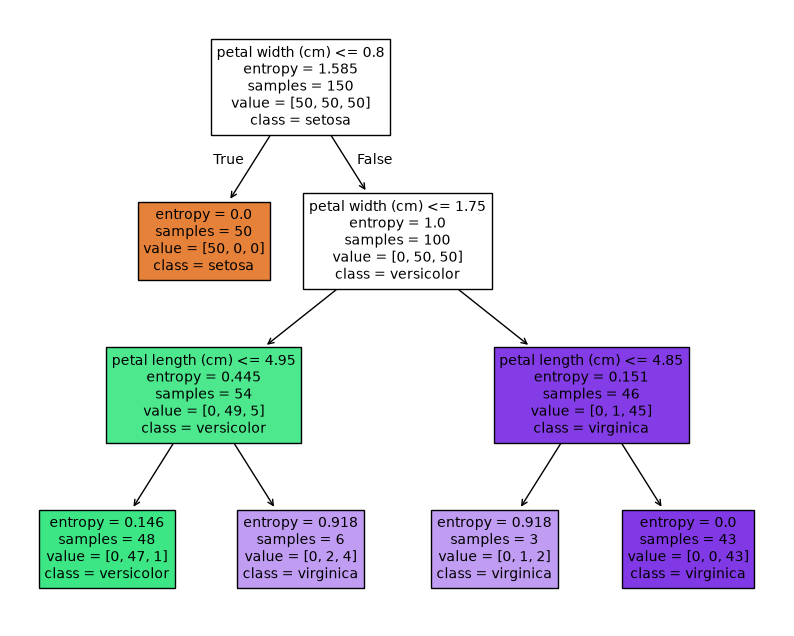

In [5]:
from matplotlib import pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier 
from sklearn import tree
import graphviz

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Train the model using DecisionTreeClassifier ID3
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model = clf.fit(X, y)

#Visualize the model using tree graph
fig = plt.figure(figsize=(10,8))
_ = tree.plot_tree(clf, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)
plt.show()
